## Operações Pontuais e Histogramas


Chamamos de **operações pontuais** (ou pointwise operations) porque o novo valor de um pixel em `(x, y)` depende apenas do valor original daquele mesmo pixel. Não há influência dos seus vizinhos, o que torna essas operações computacionalmente muito rápidas.

In [1]:
import os

for i in  range(10):
    dir_text = !dir
    if any([".venv" in text for text in dir_text]):
        print(".venv encontrado")
        break
    else:
        print(f'{i} - os.chdir("..")')
        os.chdir("..")


%load_ext autoreload
%autoreload 2

0 - os.chdir("..")
1 - os.chdir("..")


.venv encontrado


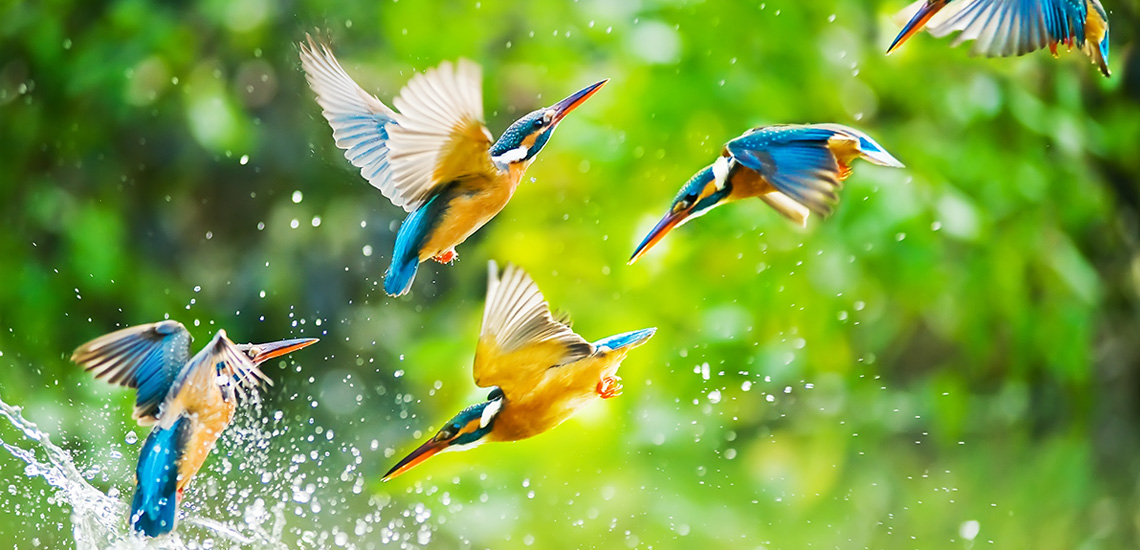

In [2]:
from libs import utils
import numpy as np

# Define os parâmetros
alpha = 1.5  # Contraste (escala de multiplicação)
beta = 30    # Brilho (valor somado)

# 1. Caregar uma imagem 
path = "data/images/beija-flor.jpg"
image = utils.read_image(path, use="pillow")

# 2. Coordenada do pixel
coord_xy = (100, 200)

# 3. Obter valor original do pixel
value_rgb = utils.get_pixel(image, coord_xy=coord_xy)
value_rgb = np.array(value_rgb)

# 4. Aplicar a formula para alterar o pixel
value_rgb = value_rgb * alpha + beta # aplica a fórmula de contraste e brilho.
value_rgb = tuple(np.array(value_rgb, dtype=int))

# 5. Garantir que os valores estejam entre 0 e 255
    # O np.clip() é usado para garantir que os valores estejam dentro do intervalo [0, 255].
    # O .astype(int) é usado para converter os valores para inteiros (como exigido pelo Pillow/OpenCV).
value_rgb = np.clip(value_rgb, a_min=0, a_max=255).astype(int)

# 6. Atualizar o pixel na imagem
utils.set_pixel_value(image, coord_xy, value=tuple(value_rgb))


In [3]:
img = np.array([1, 2, 3, 4, 5])

img + 10

array([11, 12, 13, 14, 15])

In [4]:
from PIL import Image

def apply_contrast_brightness(image, alpha=1.5, beta=30):
    """
    Aplica o contraste e o brilho a uma imagem.
    """
    image_np = np.array(image).astype(np.float32)
    image_np = image_np * alpha + beta
    image_np = np.clip(image_np, 0, 255).astype(np.uint8)
    return Image.fromarray(image_np)

image_result = apply_contrast_brightness(image)


In [5]:
def apply_grayscale(image):
    """
    Aplica grayscale a uma imagem.
    """
    img_array = np.array(image)
    grayscale = np.mean(img_array, axis=2).astype(np.uint8)
    return Image.fromarray(grayscale)

In [6]:
from libs import utils
from libs import threshold
import numpy as np
from PIL import Image




image_grayscale = apply_grayscale(image)

# Adaptativo
adapt = threshold.threshold_adaptive_mean(image=image_grayscale, block_size=15, C=10)
adapt.show()

# Otsu manual
otsu = threshold.threshold_otsu_manual(image=image_grayscale)
otsu.show()

# Percentil
perc = threshold.threshold_percentile(image=image_grayscale, percentile=85)
perc.show()


In [31]:
import numpy as np
from PIL import Image

import cv2
from typing import Union


image_dark = utils.read_image("data/images/image1.png", use="pillow") 
# clahe_color(image_dark, clip_limit=0.1)

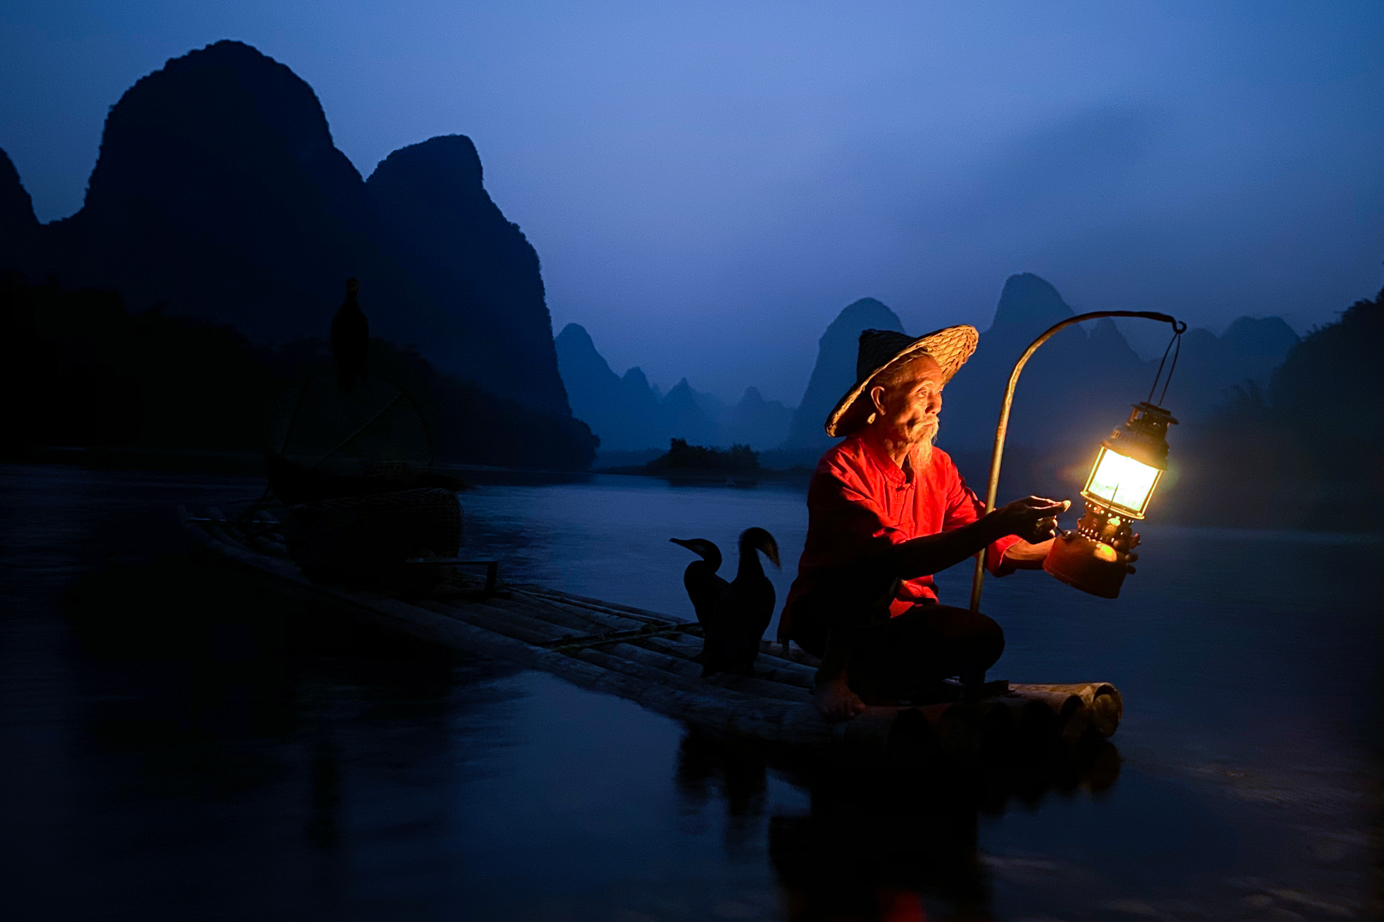

In [8]:
image_dark

In [9]:
import cv2
import numpy as np

# Carrega a imagem
imagem = cv2.imread(path)

# Define os parâmetros
alpha = 1.5  # Contraste
beta = 30    # Brilho

# Aplica a transformação
imagem_transformada = cv2.convertScaleAbs(imagem, alpha=alpha, beta=beta)

# Exibe a imagem original e transformada
cv2.imshow('Original', imagem)
cv2.imshow('Brilho e Contraste', imagem_transformada)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [10]:
def apply_contrast_brightness(image, alpha=1.5, beta=30):
    """
    Aplica o contraste e o brilho a uma imagem.
    """
    image = image.copy()
    for height in range(image.size[0]):
        for width in range(image.size[1]):
            # 3. Obter valor original do pixel
            value_rgb = utils.get_pixel(image, coord_xy=(height, width))
            value_rgb = np.array(value_rgb)

            # 4. Aplicar a formula para alterar o pixel
            value_rgb = value_rgb * alpha + beta # aplica a fórmula de contraste e brilho.
            value_rgb = tuple(np.array(value_rgb, dtype=int))

            # 5. Garantir que os valores estejam entre 0 e 255
                # O np.clip() é usado para garantir que os valores estejam dentro do intervalo [0, 255].
                # O .astype(int) é usado para converter os valores para inteiros (como exigido pelo Pillow/OpenCV).
            value_rgb = np.clip(value_rgb, a_min=0, a_max=255).astype(int)

            # 6. Atualizar o pixel na imagem
            image = utils.set_pixel_value(image, coord_xy=(height, width), value=tuple(value_rgb))

    return image